# Nhiệm vụ Ngày 1: Phân tích NDVI & NDBI của Hà Nội cấp Quận/Huyện (2023-2024)

## Mục tiêu:
1. **Xử lý Vector**: Tải và nạp ranh giới hành chính Hà Nội (đến cấp Quận/Huyện) vào Google Earth Engine.
2. **Xử lý Raster**: Sử dụng GEE API truy vấn kho ảnh Sentinel-2 và Landsat 8 bao phủ Hà Nội trong năm 2023-2024.
3. **Lập trình**: Lọc mây, tính toán chỉ số NDVI (Cây xanh) và NDBI (Đô thị), cắt ảnh theo ranh giới và tính giá trị trung bình cho từng Quận/Huyện.

In [1]:
!pip install earthengine-api geemap geopandas pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.4 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import geopandas as gpd
import pandas as pd

# Xác thực và Khởi tạo Google Earth Engine
try:
    ee.Initialize(project='crested-library-500309-i2')
    print("GEE Initialized Successfully!")
except Exception as e:
    # Trong Colab có thể cần chạy ee.Authenticate() trước
    ee.Authenticate()
    ee.Initialize(project='crested-library-500309-i2')
    print("GEE Authenticated & Initialized Successfully!")

GEE Authenticated & Initialized Successfully!


## Bước 1: Nạp ranh giới hành chính Hà Nội (Vector)
Chúng ta sẽ sử dụng file GeoJSON ranh giới hành chính cấp huyện của Việt Nam từ cổng dữ liệu Open Development Mekong, lọc riêng Hà Nội và nạp vào GEE.

In [3]:
# Tải file địa giới hành chính từ Open Development Mekong
geojson_url = "https://data.opendevelopmentmekong.net/dataset/6f054351-bf2c-422e-8deb-0a511d63a315/resource/78b3fb31-8c96-47d3-af64-d1a6e168e2ea/download/diaphanhuyen.geojson"

print("Loading GeoJSON...")
gdf = gpd.read_file(geojson_url)
hanoi_gdf = gdf[gdf['Ten_Tinh'] == 'Hà Nội'].copy()
print(f"Loaded {len(hanoi_gdf)} districts/towns for Hanoi.")

# Chuyển đổi GeoPandas DataFrame sang Earth Engine FeatureCollection
hanoi_fc = geemap.gdf_to_ee(hanoi_gdf)
print("Vector successfully loaded into Earth Engine!")

Loading GeoJSON...
Loaded 29 districts/towns for Hanoi.
Vector successfully loaded into Earth Engine!


## Bước 2: Truy vấn & Xử lý Raster (Sentinel-2 và Landsat 8)
Chúng ta lọc mây, tính toán NDVI & NDBI và tạo ảnh Composite (trung vị - median) đại diện cho giai đoạn 2023-2024.

In [4]:
start_date = '2023-01-01'
end_date = '2024-12-31'

# 1. Hàm lọc mây cho Sentinel-2
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask)

# 2. Hàm lọc mây và hiệu chỉnh Landsat 8 (Level 2 Surface Reflectance)
def maskL8clouds(image):
    qa = image.select('QA_PIXEL')
    cloudShadowBitMask = 1 << 3
    cloudBitMask = 1 << 4
    mask = qa.bitwiseAnd(cloudShadowBitMask).eq(0).And(qa.bitwiseAnd(cloudBitMask).eq(0))
    # Hiệu chỉnh hệ số tỷ lệ phản xạ
    optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    image = image.addBands(optical_bands, overwrite=True)
    return image.updateMask(mask)

# 3. Hàm tính NDVI & NDBI cho Sentinel-2
def addS2Indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    return image.addBands([ndvi, ndbi])

# 4. Hàm tính NDVI & NDBI cho Landsat 8
def addL8Indices(image):
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')
    return image.addBands([ndvi, ndbi])

# Truy vấn kho ảnh từ GEE
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(hanoi_fc)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)))

l8_col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
          .filterBounds(hanoi_fc)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUD_COVER', 10)))

print(f"Sentinel-2 images found: {s2_col.size().getInfo()}")
print(f"Landsat 8 images found: {l8_col.size().getInfo()}")

# Tạo ảnh Median Composite và Clip theo Hà Nội
s2_composite = s2_col.map(maskS2clouds).map(addS2Indices).median().clip(hanoi_fc)
l8_composite = l8_col.map(maskL8clouds).map(addL8Indices).median().clip(hanoi_fc)
print("Raster composites successfully processed and clipped!")

Sentinel-2 images found: 37
Landsat 8 images found: 18
Raster composites successfully processed and clipped!


## Bước 3: Tính toán NDVI & NDBI trung bình cho từng Quận/Huyện
Chúng ta sử dụng `reduceRegions` để tính giá trị trung bình trên từng đa giác của mỗi Quận/Huyện.

In [5]:
print("Calculating mean NDVI and NDBI per district...")

# Tính giá trị trung bình cho Sentinel-2 (phân giải 10m)
s2_reduced = s2_composite.select(['NDVI', 'NDBI']).reduceRegions(
    collection=hanoi_fc,
    reducer=ee.Reducer.mean(),
    scale=10
)

# Tính giá trị trung bình cho Landsat 8 (phân giải 30m)
l8_reduced = l8_composite.select(['NDVI', 'NDBI']).reduceRegions(
    collection=hanoi_fc,
    reducer=ee.Reducer.mean(),
    scale=30
)

# Lấy kết quả về Python
s2_info = s2_reduced.getInfo()
l8_info = l8_reduced.getInfo()

# Parse dữ liệu và chuẩn bị DataFrame
s2_dict = {}
for feat in s2_info['features']:
    props = feat['properties']
    dist_name = props.get('Ten_Huyen', 'Unknown')
    s2_dict[dist_name] = {
        'S2_NDVI': props.get('NDVI'),
        'S2_NDBI': props.get('NDBI')
    }

l8_dict = {}
for feat in l8_info['features']:
    props = feat['properties']
    dist_name = props.get('Ten_Huyen', 'Unknown')
    l8_dict[dist_name] = {
        'L8_NDVI': props.get('NDVI'),
        'L8_NDBI': props.get('NDBI')
    }

# Ghép dữ liệu tổng hợp
rows = []
for idx, row in hanoi_gdf.iterrows():
    dist_name = row['Ten_Huyen']
    dan_so = row['Dan_So']
    code_vung = row['Code_vung']

    s2_vals = s2_dict.get(dist_name, {'S2_NDVI': None, 'S2_NDBI': None})
    l8_vals = l8_dict.get(dist_name, {'L8_NDVI': None, 'L8_NDBI': None})

    rows.append({
        'Code_Vung': code_vung,
        'District_Name': dist_name,
        'Population_2009': dan_so,
        'S2_NDVI_Mean': s2_vals['S2_NDVI'],
        'S2_NDBI_Mean': s2_vals['S2_NDBI'],
        'L8_NDVI_Mean': l8_vals['L8_NDVI'],
        'L8_NDBI_Mean': l8_vals['L8_NDBI']
    })

df_result = pd.DataFrame(rows).sort_values(by='District_Name')
df_result.to_csv('hanoi_district_indices.csv', index=False, encoding='utf-8-sig')
print("Processing complete! Table of results:")
print(df_result.to_string(index=False))

Calculating mean NDVI and NDBI per district...
Processing complete! Table of results:
Code_Vung District_Name  Population_2009  S2_NDVI_Mean  S2_NDBI_Mean  L8_NDVI_Mean  L8_NDBI_Mean
    01001       Ba Dinh           225910      0.243788      0.040461      0.259491     -0.058784
    01271         Ba Vi           246120      0.508939     -0.156260      0.557416     -0.235890
    01005      Cau Giay           225643      0.233865      0.061000      0.249593     -0.033650
    01277     Chuong My           286359      0.435260     -0.160938      0.485304     -0.221380
    01273    Dan Phuong           142480      0.371547     -0.121509      0.392298     -0.195512
    01017      Dong Anh           333337      0.402880     -0.101522      0.384297     -0.119964
    01006       Dong Da           370117      0.193904      0.132665      0.202241      0.026784
    01018       Gia Lam           229735      0.397579     -0.115897      0.406408     -0.175786
    01268       Ha Dong           233126 

## Bước 4: Trực quan hóa bản đồ tương tác
Sử dụng thư viện `geemap` để hiển thị ranh giới và lớp phủ chỉ số NDVI/NDBI trực quan trên bản đồ.

In [8]:
Map = geemap.Map()
Map.centerObject(hanoi_fc, 10)


# Vẽ ranh giới huyện màu đỏ rỗng ruột
Map.addLayer(hanoi_fc, {'color': 'red', 'fillColor': '00000000'}, 'Hanoi Districts Boundary')

Map

Map(center=[20.999184677179052, 105.69885038571539], controls=(WidgetControl(options=['position', 'transparent…

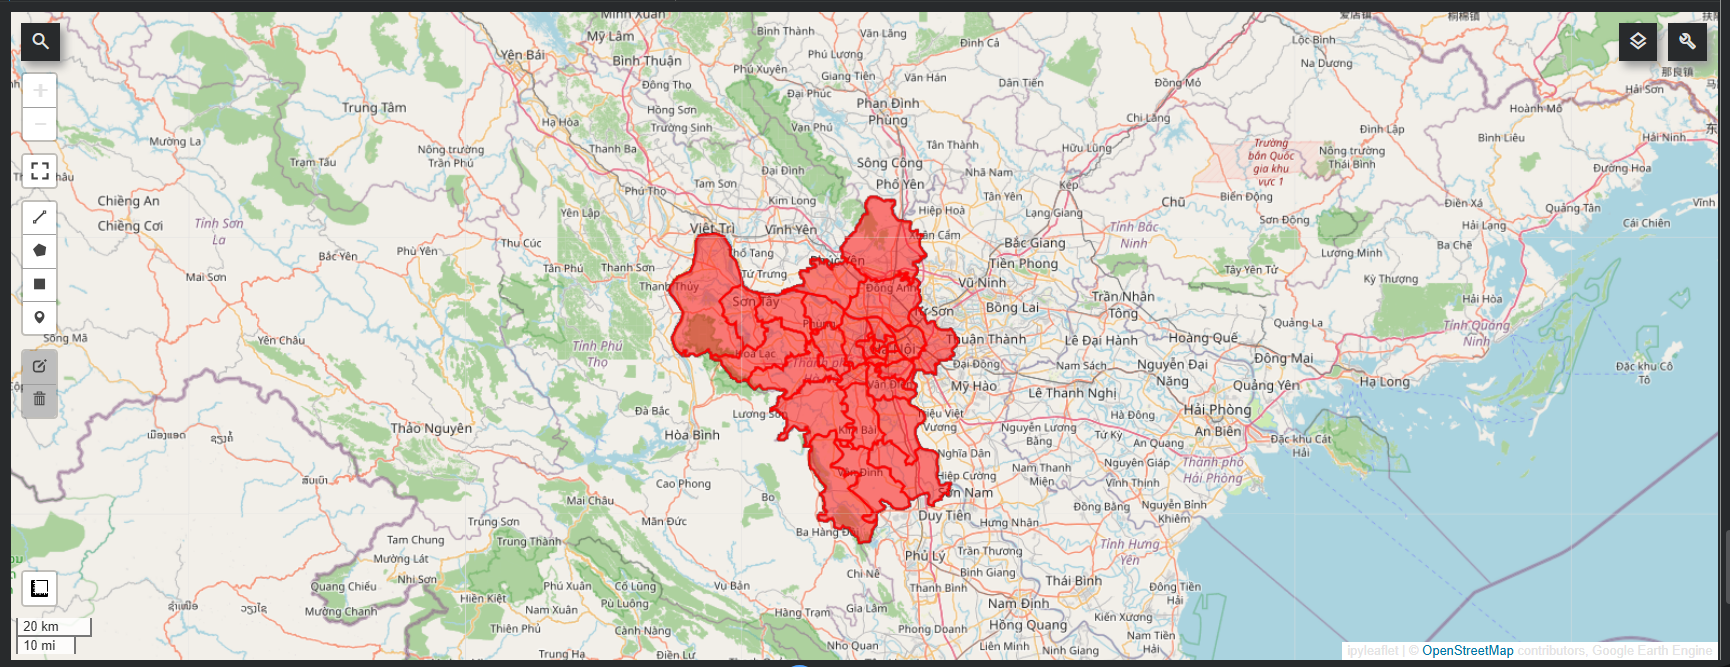